In [40]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

In [37]:
snapnum = 40

In [38]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [41]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [42]:
h = 0.6774

In [43]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [45]:
mfof = np.log10(halos["GroupMass"]*1e10)

In [44]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [46]:
def halo_mass_function(masses, boxsize, log_M_min=8.0, log_M_max=15.0, delta_log_M=0.1,
                       calculate_err=True, logSFR_min=None, sfrs=None):
    nbins = int(1 + (log_M_max - log_M_min)/delta_log_M)
    bins = np.linspace(log_M_min, log_M_max, num=nbins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    if logSFR_min is not None:
        mask = sfrs > logSFR_min
        masses = masses[mask]
    
    num_halos = np.histogram(masses, bins)[0]

    normalisation = (boxsize**3) * delta_log_M

    if calculate_err:
        # Calculate error bars assuming Poisson distribution in each bin
        errs = np.sqrt(num_halos)/normalisation

    bin_counts = num_halos / normalisation
    
    return bin_centers, bin_counts, errs

    

In [80]:
boxsize_tng = 205


In [93]:
bin_centers1, bin_counts1, errs1 = halo_mass_function(mvir, boxsize_tng, log_M_min=8.9,
                                                  log_M_max=15.0, delta_log_M=0.1, logSFR_min=-5, sfrs=group_sfrs)
bin_centers2, bin_counts2, errs2 = halo_mass_function(mfof, boxsize_tng, log_M_min=8.9,
                                                  log_M_max=15.0, delta_log_M=0.1, logSFR_min=-5, sfrs=group_sfrs)

In [73]:

def logging(bin_centers, bin_counts, errs):
    log_bin_center = []
    log_bin_counts = []
    log_up_errs = []
    log_down_errs = []
    one_halo_bin_centers = []
    one_halo_bin_counts = []
    
    for i, m in enumerate(bin_centers):
        if bin_counts[i] > 0:
            if bin_counts[i] == errs[i]:
                one_halo_bin_centers.append(m)
                one_halo_bin_counts.append(np.log10(bin_counts[i]))
            
            else:
                log_bin_center.append(m)
                log_bin_counts.append(np.log10(bin_counts[i]))
                up_err = np.log10(bin_counts[i]+errs[i]) - np.log10(bin_counts[i])
                down_err = np.log10(bin_counts[i]) - np.log10(bin_counts[i]-errs[i])
                log_up_errs.append(up_err)
                log_down_errs.append(down_err)
    return log_bin_center, log_bin_counts, log_up_errs, log_down_errs, one_halo_bin_centers, one_halo_bin_counts


In [94]:
log_bin_centers1, log_bin_counts1, log_up_errs1, log_down_errs1, one_halo_bin_centers1, one_halo_bin_counts1 = logging(bin_centers1, bin_counts1, errs1)
log_bin_centers2, log_bin_counts2, log_up_errs2, log_down_errs2, one_halo_bin_centers2, one_halo_bin_counts2 = logging(bin_centers2, bin_counts2, errs2)

In [51]:
from colossus.cosmology import cosmology
from colossus.lss import mass_function

def jenkins_hmf(log_bin_centers, z):
    dlog10M = 0.1
    mass1 = 10**np.array(log_bin_centers)
    cosmology.setCosmology('planck15')
    mfunc1 = mass_function.massFunction(mass1, z, mdef = 'fof', model = 'watson13', #M is in Msun/h
                                           ps_args={"model":"eisenstein98", "path":None}, 
                                            q_in = "M", q_out = 'dndlnM')

    dlnM = np.log(10**dlog10M)
    dndlog10m_colossus1 = []
    for i, dndlnm in enumerate(mfunc1):
        M1 = 10**(np.log10(mass1[i]) - dlog10M/2)
        M2 = 10**(np.log10(mass1[i]) + dlog10M/2)
        dM = M2 - M1
        #print("{:e}".format(dM))
        dndlog10m = dndlnm * dlnM / dlog10M
        dndlog10m_colossus1.append(dndlog10m)
    return dndlog10m_colossus1

In [99]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 5)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [53]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

(9.0, 14.5)

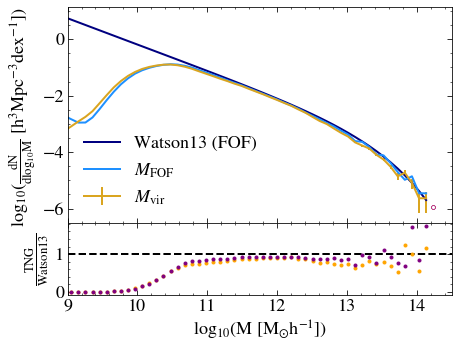

In [100]:
import matplotlib.pyplot as plt
#Main plot
z=1.5
fig1 = plt.figure(1)
frame1 = fig1.add_axes((.1,.3,.8,.6))

jenkins_mass = log_bin_centers1
plt.plot(jenkins_mass, np.log10(jenkins_hmf(jenkins_mass, z=z)), label="Watson13 (FOF)", c="navy")

# pinocchio1536 = plt.errorbar(log_bin_centers2, log_bin_counts2, yerr=[log_down_errs2, log_up_errs2], fmt=".",
#             label="$M_{\mathrm{FOF}}$", c="DodgerBlue")
# pinocchio1024 = plt.errorbar(log_bin_centers1, log_bin_counts1, yerr=[log_down_errs1, log_up_errs1], fmt=".",
#             label="$M_{\mathrm{vir}}$", c="goldenrod")

pinocchio1536 = plt.plot(log_bin_centers2, log_bin_counts2,
            label="$M_{\mathrm{FOF}}$", c="DodgerBlue")
pinocchio1024 = plt.errorbar(log_bin_centers1, log_bin_counts1, yerr=[log_down_errs1, log_up_errs1],
            label="$M_{\mathrm{vir}}$", c="goldenrod")

plt.errorbar(one_halo_bin_centers1, one_halo_bin_counts1, fmt="o", c="blue", mfc="none", ms=4, mew=0.5)
plt.errorbar(one_halo_bin_centers2, one_halo_bin_counts2, fmt="o", c="red", mfc="none", ms=4, mew=0.5)
frame1.set_xticklabels([])
plt.ylabel(r" log$_{10}$($\rm \frac{dN}{d\log_{10}M}$ [$\rm h^3 Mpc^{-3} dex^{-1}$])", loc="top",
          )
#plt.plot([np.log10(mass_for_npart1)]*2,[-8, 1], linestyle="dotted", c = "blue")
#plt.plot([np.log10(mass_for_npart2)]*2,[-8, 1], linestyle="dotted", c = "red")
plt.xlim(9, 14.5)
#plt.ylim(-7.5,1.5)

#npart_line = plt.plot([], [], color="grey", linestyle="dotted", label="100-particle halo")

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()
#specify order of items in legend
order = [0,2,3,1]
#add legend to plot
#plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
plt.legend()

#Ratio plot
jenkins1 = jenkins_hmf(log_bin_centers1, z=z)
jenkins2 = jenkins_hmf(log_bin_centers2, z=z)
ratio1 = [m/n for m,n in zip(10**np.array(log_bin_counts1), jenkins1)]
ratio2 = [m/n for m,n in zip(10**np.array(log_bin_counts2), jenkins2)]
frame2 = fig1.add_axes((.1,.1,.8,.2))
plt.errorbar(log_bin_centers1, ratio1, fmt=".", c="orange")
plt.errorbar(log_bin_centers2, ratio2, fmt=".", c="purple")
plt.plot([9, 15], [1,1], linestyle="dashed", c="black")
#plt.plot([np.log10(mass_for_npart1)]*2,[0.4, 1.7], linestyle="dotted", c ="blue")
#plt.plot([np.log10(mass_for_npart2)]*2,[0.4, 1.7], linestyle="dotted", c ="red")
plt.xlabel(r"log$_{10}$(M [$\rm M_{\odot} h^{-1}$])")
plt.ylabel(r"$\rm \frac{TNG}{Watson13}$")
plt.xlim(9,14.5)
#plt.ylim(0.3, 1.7)
#plt.savefig("../figures/hmf_fof_vs_vir_nonzero_sfr.pdf", format="pdf", bbox_inches="tight")

In [64]:
len(log_bin_counts1)

62

In [113]:
print(log_bin_centers1)

[8.950833333333334, 9.0525, 9.154166666666667, 9.255833333333333, 9.3575, 9.459166666666667, 9.560833333333333, 9.6625, 9.764166666666666, 9.865833333333335, 9.967500000000001, 10.069166666666668, 10.170833333333334, 10.2725, 10.374166666666667, 10.475833333333334, 10.5775, 10.679166666666667, 10.780833333333334, 10.8825, 10.984166666666667, 11.085833333333333, 11.1875, 11.289166666666667, 11.390833333333333, 11.4925, 11.594166666666666, 11.695833333333333, 11.7975, 11.899166666666666, 12.000833333333333, 12.1025, 12.204166666666666, 12.305833333333332, 12.407499999999999, 12.509166666666667, 12.610833333333334, 12.7125, 12.814166666666667, 12.915833333333333, 13.0175, 13.119166666666667, 13.220833333333333, 13.3225, 13.424166666666666, 13.525833333333333, 13.6275, 13.729166666666666, 13.830833333333334, 13.932500000000001, 14.034166666666668, 14.135833333333334]


In [114]:
print(log_bin_centers2)

[8.950833333333334, 9.0525, 9.154166666666667, 9.255833333333333, 9.3575, 9.459166666666667, 9.560833333333333, 9.6625, 9.764166666666666, 9.865833333333335, 9.967500000000001, 10.069166666666668, 10.170833333333334, 10.2725, 10.374166666666667, 10.475833333333334, 10.5775, 10.679166666666667, 10.780833333333334, 10.8825, 10.984166666666667, 11.085833333333333, 11.1875, 11.289166666666667, 11.390833333333333, 11.4925, 11.594166666666666, 11.695833333333333, 11.7975, 11.899166666666666, 12.000833333333333, 12.1025, 12.204166666666666, 12.305833333333332, 12.407499999999999, 12.509166666666667, 12.610833333333334, 12.7125, 12.814166666666667, 12.915833333333333, 13.0175, 13.119166666666667, 13.220833333333333, 13.3225, 13.424166666666666, 13.525833333333333, 13.6275, 13.729166666666666, 13.830833333333334, 13.932500000000001, 14.034166666666668, 14.135833333333334]


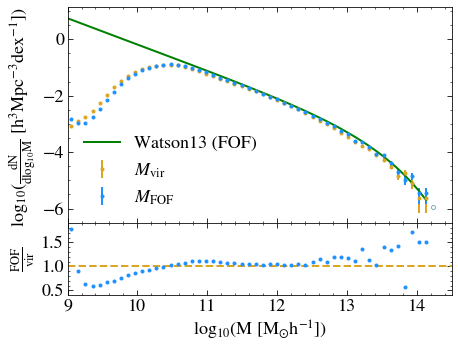

In [123]:
import matplotlib.pyplot as plt
#Main plot
z=1.5
fig1 = plt.figure(1)
frame1 = fig1.add_axes((.1,.3,.8,.6))

jenkins_mass = log_bin_centers1
plt.plot(jenkins_mass, np.log10(jenkins_hmf(jenkins_mass, z=z)), label="Watson13 (FOF)", c="green")

pinocchio1024 = plt.errorbar(log_bin_centers1, log_bin_counts1, yerr=[log_down_errs1, log_up_errs1], fmt=".",
            label="$M_{\mathrm{vir}}$", c="goldenrod")
pinocchio1536 = plt.errorbar(log_bin_centers2, log_bin_counts2, yerr=[log_down_errs2, log_up_errs2], fmt=".",
            label="$M_{\mathrm{FOF}}$", c="DodgerBlue")


# pinocchio1536 = plt.plot(log_bin_centers2, log_bin_counts2,
#             label="$M_{\mathrm{FOF}}$", c="DodgerBlue")
# pinocchio1024 = plt.errorbar(log_bin_centers1, log_bin_counts1, yerr=[log_down_errs1, log_up_errs1],
#             label="$M_{\mathrm{vir}}$", c="goldenrod")

plt.errorbar(one_halo_bin_centers1, one_halo_bin_counts1, fmt="o", c="goldenrod", mfc="none", ms=4, mew=0.5)
plt.errorbar(one_halo_bin_centers2, one_halo_bin_counts2, fmt="o", c="DodgerBlue", mfc="none", ms=4, mew=0.5)
frame1.set_xticklabels([])
plt.ylabel(r" log$_{10}$($\rm \frac{dN}{d\log_{10}M}$ [$\rm h^3 Mpc^{-3} dex^{-1}$])", loc="top",
          )
#plt.plot([np.log10(mass_for_npart1)]*2,[-8, 1], linestyle="dotted", c = "blue")
#plt.plot([np.log10(mass_for_npart2)]*2,[-8, 1], linestyle="dotted", c = "red")
plt.xlim(9, 14.5)
#plt.ylim(-7.5,1.5)

#npart_line = plt.plot([], [], color="grey", linestyle="dotted", label="100-particle halo")

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()
#specify order of items in legend
order = [0,2,3,1]
#add legend to plot
#plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
plt.legend()

#Ratio plot
jenkins1 = jenkins_hmf(log_bin_centers1, z=z)
jenkins2 = jenkins_hmf(log_bin_centers2, z=z)
iend = 100
ratio1 = [m/n for m,n in zip(10**np.array(log_bin_counts2[:iend]), 10**np.array(log_bin_counts1[:iend]))]
ratio2 = [m/n for m,n in zip(10**np.array(log_bin_counts2), jenkins2)]
frame2 = fig1.add_axes((.1,.1,.8,.2))
plt.errorbar(log_bin_centers1[:iend], ratio1, fmt=".", c="DodgerBlue")
#plt.errorbar(log_bin_centers2, ratio2, fmt=".", c="purple")
plt.plot([9, 15], [1,1], linestyle="dashed", c="goldenrod")
#plt.plot([np.log10(mass_for_npart1)]*2,[0.4, 1.7], linestyle="dotted", c ="blue")
#plt.plot([np.log10(mass_for_npart2)]*2,[0.4, 1.7], linestyle="dotted", c ="red")
plt.xlabel(r"log$_{10}$(M [$\rm M_{\odot} h^{-1}$])")
plt.ylabel(r"$\rm \frac{FOF}{vir}$")
plt.xlim(9,14.5)
plt.ylim(0.4, 1.9)
#plt.savefig("../figures/hmf_fof_vs_vir_nonzero_sfr.pdf", format="pdf", bbox_inches="tight")

(0.3, 1.7)

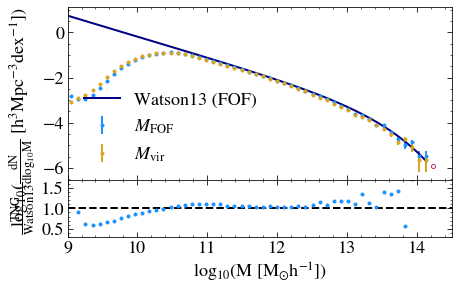

In [97]:
import matplotlib.pyplot as plt
#Main plot
z=1.5
fig1 = plt.figure(1)
frame1 = fig1.add_axes((.1,.3,.8,.6))

jenkins_mass = log_bin_centers1
plt.plot(jenkins_mass, np.log10(jenkins_hmf(jenkins_mass, z=z)), label="Watson13 (FOF)", c="navy")

pinocchio1536 = plt.errorbar(log_bin_centers2, log_bin_counts2, yerr=[log_down_errs2, log_up_errs2], fmt=".",
            label="$M_{\mathrm{FOF}}$", c="DodgerBlue")
pinocchio1024 = plt.errorbar(log_bin_centers1, log_bin_counts1, yerr=[log_down_errs1, log_up_errs1], fmt=".",
            label="$M_{\mathrm{vir}}$", c="goldenrod")

# pinocchio1536 = plt.plot(log_bin_centers2, log_bin_counts2,
#             label="$M_{\mathrm{FOF}}$", c="DodgerBlue")
# pinocchio1024 = plt.errorbar(log_bin_centers1, log_bin_counts1, yerr=[log_down_errs1, log_up_errs1],
#             label="$M_{\mathrm{vir}}$", c="goldenrod")

plt.errorbar(one_halo_bin_centers1, one_halo_bin_counts1, fmt="o", c="blue", mfc="none", ms=4, mew=0.5)
plt.errorbar(one_halo_bin_centers2, one_halo_bin_counts2, fmt="o", c="red", mfc="none", ms=4, mew=0.5)
frame1.set_xticklabels([])
plt.ylabel(r" log$_{10}$($\rm \frac{dN}{d\log_{10}M}$ [$\rm h^3 Mpc^{-3} dex^{-1}$])", loc="top",
          )
#plt.plot([np.log10(mass_for_npart1)]*2,[-8, 1], linestyle="dotted", c = "blue")
#plt.plot([np.log10(mass_for_npart2)]*2,[-8, 1], linestyle="dotted", c = "red")
plt.xlim(9, 14.5)
#plt.ylim(-7.5,1.5)

#npart_line = plt.plot([], [], color="grey", linestyle="dotted", label="100-particle halo")

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()
#specify order of items in legend
order = [0,2,3,1]
#add legend to plot
#plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
plt.legend()

#Ratio plot
jenkins1 = jenkins_hmf(log_bin_centers1, z=z)
jenkins2 = jenkins_hmf(log_bin_centers2, z=z)
iend = 50
ratio1 = [m/n for m,n in zip(10**np.array(log_bin_counts2[:iend]), 10**np.array(log_bin_counts1[:iend]))]
ratio2 = [m/n for m,n in zip(10**np.array(log_bin_counts2), jenkins2)]
frame2 = fig1.add_axes((.1,.1,.8,.2))
plt.errorbar(log_bin_centers1[:iend], ratio1, fmt=".", c="DodgerBlue")
#plt.errorbar(log_bin_centers2, ratio2, fmt=".", c="purple")
plt.plot([9, 15], [1,1], linestyle="dashed", c="black")
#plt.plot([np.log10(mass_for_npart1)]*2,[0.4, 1.7], linestyle="dotted", c ="blue")
#plt.plot([np.log10(mass_for_npart2)]*2,[0.4, 1.7], linestyle="dotted", c ="red")
plt.xlabel(r"log$_{10}$(M [$\rm M_{\odot} h^{-1}$])")
plt.ylabel(r"$\rm \frac{TNG}{Watson13}$")
plt.xlim(9,14.5)
plt.ylim(0.3, 1.7)
#plt.savefig("../figures/hmf_fof_vs_vir_nonzero_sfr.pdf", format="pdf", bbox_inches="tight")

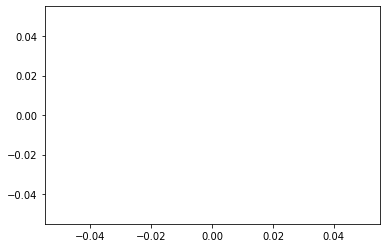

In [40]:
plt.scatter(log_bin_centers1, log_bin_counts1)
plt.scatter(log_bin_centers2, log_bin_counts2)